In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

## GE Aerospace

Epoch 1/50


/var/folders/05/19zrgd2s59z1qzk3tnng2t7m0000gn/T/ipykernel_4132/2363103896.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/Users/thuyduongle/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.6917 - val_loss: 0.0158
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.2028 - val_loss: 0.0681
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.4903 - val_loss: 0.1675
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.2157 - val_loss: 0.2543
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2139 - val_loss: 0.2653
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.3446 - val_loss: 0.2729
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.4362 - val_loss: 0.2491
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.4185 - val_loss: 0.1763
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.4668 - val_loss: 0.1136
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.5759 - val_loss: 0.0954
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.4731 - val_loss: 0.0716
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0614 - val_loss: 0.0537
Epoch 13/5

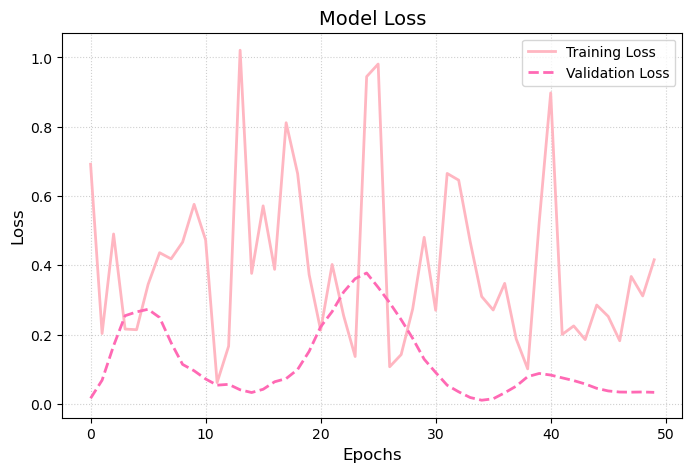

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
RMSE: 3.41
MAE: 3.41


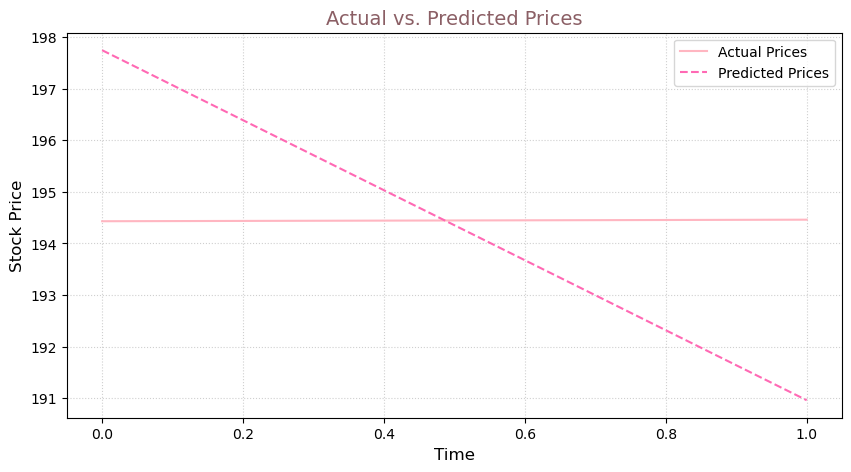

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
Tomorrow's predicted stock price: $190.96


In [83]:
# Load data
df = pd.read_csv('GE.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Normalization
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Close']])

# Create Sequences
def create_sequences(data, time_steps=25): 
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 25
X, y = create_sequences(df_scaled, time_steps)
X_train, X_test, y_train, y_test = X[:int(len(X)*0.8)], X[int(len(X)*0.8):], y[:int(len(y)*0.8)], y[int(len(y)*0.8):]

# Build RNN model
model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(time_steps, 1)),  
    Dropout(0.4),  
    SimpleRNN(50, return_sequences=False), 
    Dropout(0.4), 
    Dense(1) 
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')  

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))  

# Visualizing training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], color='#ffb6c1', linewidth=2, label='Training Loss')  
plt.plot(history.history['val_loss'], color='#ff69b4', linewidth=2, linestyle='dashed', label='Validation Loss')  
plt.title('Model Loss', fontsize=14) 
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# Predictions
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Performance Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

# Visualizing Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, color='#ffb6c1', label='Actual Prices')  
plt.plot(y_pred_inv, color='#ff69b4', linestyle='dashed', label='Predicted Prices') 
plt.title('Actual vs. Predicted Prices', fontsize=14, color='#8b5f65')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# Predicting March 13th stock price
last_sequence = X_test[-1]  
last_sequence = np.expand_dims(last_sequence, axis=0)
predicted_value = model.predict(last_sequence) 
predicted_value = scaler.inverse_transform(predicted_value.reshape(-1, 1))
print(f"Tomorrow's predicted stock price: ${predicted_value[0][0]:.2f}")

## Lockheed Martin

Epoch 1/50


/var/folders/05/19zrgd2s59z1qzk3tnng2t7m0000gn/T/ipykernel_4132/784487057.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/Users/thuyduongle/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1640 - val_loss: 0.1323
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.1004 - val_loss: 0.1006
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.4465 - val_loss: 0.0930
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.3400 - val_loss: 0.1054
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.1525 - val_loss: 0.1592
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.3286 - val_loss: 0.1917
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.2106 - val_loss: 0.1983
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.2588 - val_loss: 0.2309
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0896 - val_loss: 0.2755
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1840 - val_loss: 0.2842
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.4712 - val_loss: 0.2295
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.2975 - val_loss: 0.1821
Epoch 

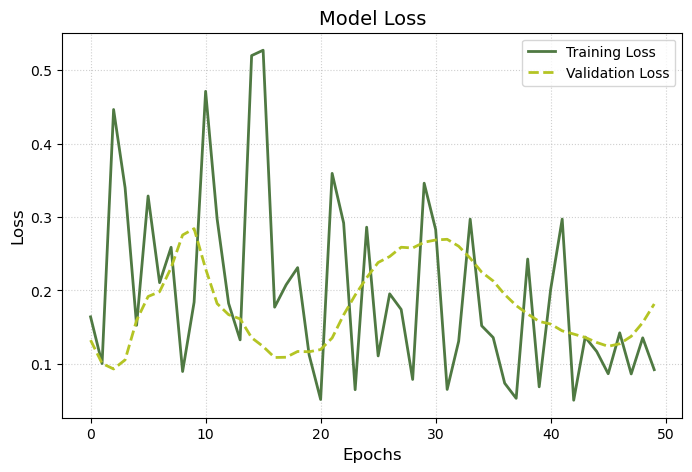

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
RMSE: 34.30
MAE: 24.93


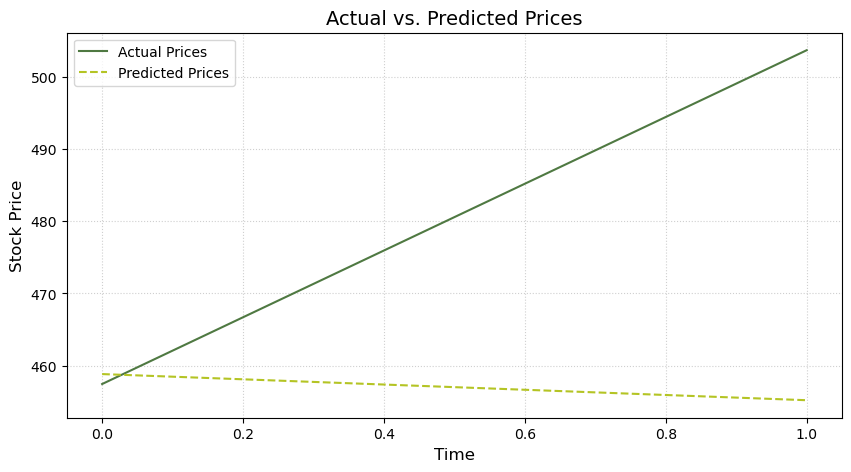

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Tomorrow's predicted stock price: $455.21


In [88]:
# Load data
df = pd.read_csv('LMT.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Normalization
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Close']])

# Create Sequences
def create_sequences(data, time_steps=25): 
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 25
X, y = create_sequences(df_scaled, time_steps)
X_train, X_test, y_train, y_test = X[:int(len(X)*0.8)], X[int(len(X)*0.8):], y[:int(len(y)*0.8)], y[int(len(y)*0.8):]

# Build RNN model
model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(time_steps, 1)),  
    Dropout(0.4),  
    SimpleRNN(50, return_sequences=False), 
    Dropout(0.4), 
    Dense(1) 
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')  

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))  

# Visualizing training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], color='#4F7942', linewidth=2, label='Training Loss')  
plt.plot(history.history['val_loss'], color='#B4C424', linewidth=2, linestyle='dashed', label='Validation Loss')  
plt.title('Model Loss', fontsize=14) 
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# Predictions
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Performance Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

# Visualizing Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, color='#4F7942', label='Actual Prices')  
plt.plot(y_pred_inv, color='#B4C424', linestyle='dashed', label='Predicted Prices') 
plt.title('Actual vs. Predicted Prices', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# Predicting March 13th stock price
last_sequence = X_test[-1]  
last_sequence = np.expand_dims(last_sequence, axis=0)
predicted_value = model.predict(last_sequence)  
predicted_value = scaler.inverse_transform(predicted_value.reshape(-1, 1))
print(f"Tomorrow's predicted stock price: ${predicted_value[0][0]:.2f}")

## Exxon Mobile

Epoch 1/50


/var/folders/05/19zrgd2s59z1qzk3tnng2t7m0000gn/T/ipykernel_4132/3855352129.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/Users/thuyduongle/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.4241 - val_loss: 0.7371
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.3794 - val_loss: 0.4041
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 1.7891 - val_loss: 0.1871
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.9422 - val_loss: 0.0426
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.4218 - val_loss: 0.0106
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.3688 - val_loss: 0.0331
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.1873 - val_loss: 0.0750
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.8508 - val_loss: 0.1099
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.2057 - val_loss: 0.1338
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.7453 - val_loss: 0.1036
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.5013 - val_loss: 0.0607
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2406 - val_loss: 0.0286
Epoch 13/50
1

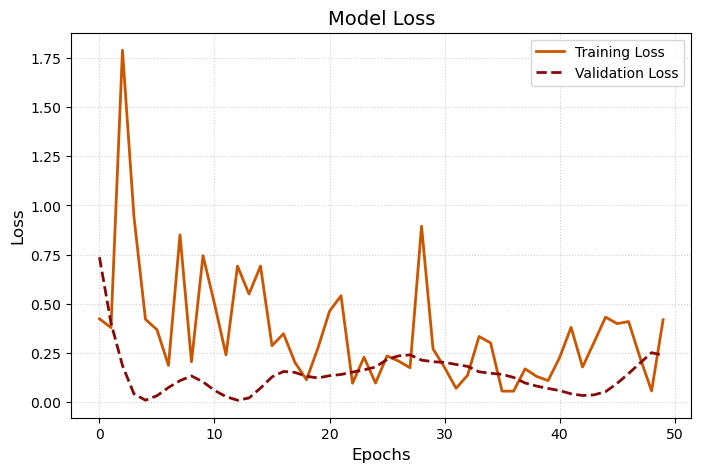

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
RMSE: 3.21
MAE: 3.21


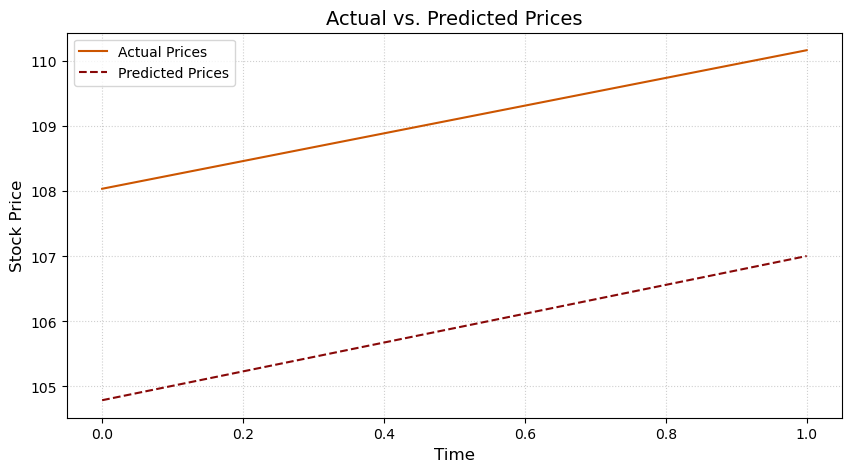

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Tomorrow's predicted stock price: $107.01


In [92]:
# Load data
df = pd.read_csv('XOM.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Normalization
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Close']])

# Create Sequences
def create_sequences(data, time_steps=25): 
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 25
X, y = create_sequences(df_scaled, time_steps)
X_train, X_test, y_train, y_test = X[:int(len(X)*0.8)], X[int(len(X)*0.8):], y[:int(len(y)*0.8)], y[int(len(y)*0.8):]

# Build RNN model
model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(time_steps, 1)),  
    Dropout(0.4),  
    SimpleRNN(50, return_sequences=False), 
    Dropout(0.4), 
    Dense(1) 
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')  

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))  

# Visualizing training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], color='#CC5500', linewidth=2, label='Training Loss')  
plt.plot(history.history['val_loss'], color='#880808', linewidth=2, linestyle='dashed', label='Validation Loss')  
plt.title('Model Loss', fontsize=14) 
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# Predictions
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Performance Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

# Visualizing Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, color='#CC5500', label='Actual Prices')  
plt.plot(y_pred_inv, color='#880808', linestyle='dashed', label='Predicted Prices') 
plt.title('Actual vs. Predicted Prices', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# Predicting March 13th stock price
last_sequence = X_test[-1]  
last_sequence = np.expand_dims(last_sequence, axis=0)
predicted_value = model.predict(last_sequence) 
predicted_value = scaler.inverse_transform(predicted_value.reshape(-1, 1))
print(f"Tomorrow's predicted stock price: ${predicted_value[0][0]:.2f}")